# Imports

In [1]:
# Import necessary libraries
from pyhgf.model import Network
from scipy.stats import norm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.voting import generate_observations, generate_candidates, individual_vote, init_preferences,kl_divergence
import colorsys
# Import JAX and related modules
import jax.numpy as jnp
from jax import random, vmap
from jax.tree_util import Partial
import time
import numpy as np
from scipy.stats import norm, halfnorm
import seaborn as sns

# Style

In [2]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

# Tailles de police
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Grille
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = "--"
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['grid.color'] = "#e0e0e0"
plt.rcParams['grid.linewidth'] = 0.5

# Fond et bordures
plt.rcParams['axes.facecolor'] = "#f9f9f9"
plt.rcParams['figure.facecolor'] = "#f9f9f9"
plt.rcParams['axes.edgecolor'] = "#e0e0e0"
plt.rcParams['axes.linewidth'] = 0.8

# Légende
plt.rcParams['legend.facecolor'] = "#f9f9f9"
plt.rcParams['legend.edgecolor'] = "#e0e0e0"
plt.rcParams['legend.fontsize'] = 10

# Autres
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)


# Parameters

In [3]:
# --- Simulation parameters ---
n_preferences = 2              # Number of preference dimensions
voting_system = "basic"        # Options: "basic", "basic (ToM)", "ranked", "quadratic"
n_candidates = 2             # Number of candidates per round
n_simulations = 100            # Number of simulations to run
n_agents = 100 * n_simulations  # Total number of agents

# Mask for candidate selection (useful if you later simulate multiple rounds)
mask = np.ones(n_candidates, dtype=bool)

# Generate environmental observations (e.g., signals that influence agent updates)
input_data = generate_observations(
    n_nodes=n_preferences, 
    n_steps=200, 
    scenario=1
)

# --- Agent parameters ---
tonic_volatilities = np.random.normal(loc=-3.0, scale=1.0, size=n_agents)

prefs = init_preferences(n_agents, n_preferences)
all_mus = prefs["mean"]         # Means of preference distributions per agent
all_pis = prefs["precision"]    # Precisions (inverse variance) per agent
all_sigmas = 1 / np.sqrt(all_pis)

# --- Candidate distributions ---
# Option 1: random generation
# candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)

# Option 2: manual definitions (deterministic reproducibility)
manual_means_candidates = [
    [3.0, 3.0],
    [2.0, 6.0]
]
manual_precisions_candidates = [
    [1.0, 0.8],
    [0.3, 1.0]
]

candidate_list = [
    (np.array(m), np.array(p)) 
    for m, p in zip(manual_means_candidates, manual_precisions_candidates)
]


# Plot 1 - Preference Distribution

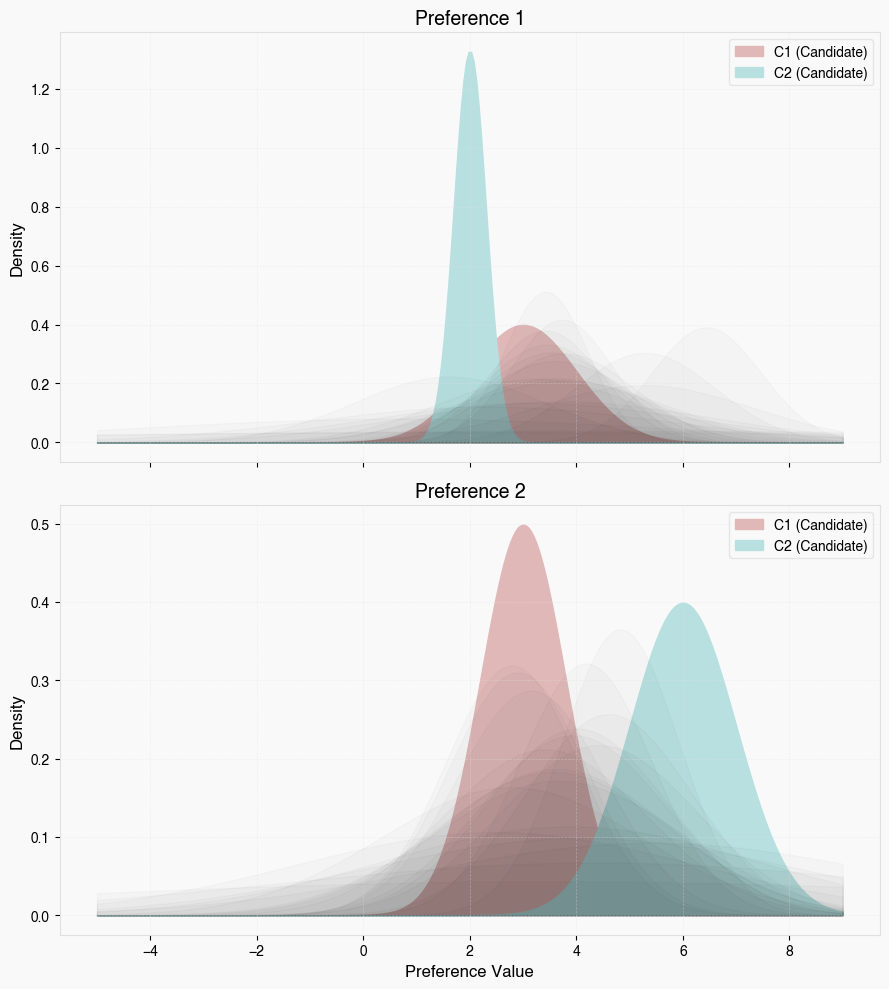

In [4]:
x_min, x_max = -5, 9
x_vals = np.linspace(x_min, x_max, 300)
rows = []

# --- Candidates ---
for i, (mus, sigmas) in enumerate(candidate_list):
    for pref in range(n_preferences):
        pdf = norm.pdf(x_vals, loc=mus[pref], scale=sigmas[pref])
        rows.extend([{
            "group": "Candidate",
            "id": f"C{i+1}",
            "preference": f"Preference {pref+1}",
            "x": x,
            "pdf": y
        } for x, y in zip(x_vals, pdf)])

# --- Agents ---
for i in range(n_agents):
    mus = all_mus[i]
    sigmas = all_sigmas[i]
    for pref in range(n_preferences):
        pdf = norm.pdf(x_vals, loc=mus[pref], scale=sigmas[pref])
        rows.extend([{
            "group": "Agent",
            "id": f"A{i+1}",
            "preference": f"Preference {pref+1}",
            "x": x,
            "pdf": y
        } for x, y in zip(x_vals, pdf)])

# --- Final DataFrame ---
df = pd.DataFrame(rows)

# --- Pastel colors for candidates ---
candidate_ids = [c for c in df["id"].unique() if c.startswith("C")]
n_candidates = len(candidate_ids)
colors = [colorsys.hls_to_rgb(i / n_candidates, 0.8, 0.4) for i in range(n_candidates)]

# --- Plot ---
preferences = df["preference"].unique()
agents_to_plot = [a for a in df["id"].unique() if a.startswith("A")][:20]  # first 20 agents

fig, axes = plt.subplots(len(preferences), 1, figsize=(9, 5 * len(preferences)), sharex=True)
axes = [axes] if len(preferences) == 1 else axes

for ax, pref in zip(axes, preferences):
    sub_df = df[df["preference"] == pref]

    # Plot candidates
    for j, cand in enumerate(candidate_ids):
        cand_df = sub_df[sub_df["id"] == cand]
        ax.fill_between(cand_df["x"], cand_df["pdf"], color=colors[j], label=f"{cand} (Candidate)")

    # Plot agents
    for agent in agents_to_plot:
        agent_df = sub_df[sub_df["id"] == agent]
        ax.fill_between(agent_df["x"], agent_df["pdf"], color="black", alpha=0.02)

    ax.set_title(pref)
    ax.set_ylabel("Density")
    ax.legend()

axes[-1].set_xlabel("Preference Value")
plt.tight_layout()
plt.show()


In [5]:
agent_df["pdf"]

12900    0.000082
12901    0.000089
12902    0.000097
12903    0.000105
12904    0.000114
           ...   
13195    0.010138
13196    0.009625
13197    0.009135
13198    0.008665
13199    0.008216
Name: pdf, Length: 300, dtype: float64

# Plots 2 - Belief evolution

## Scenario 1

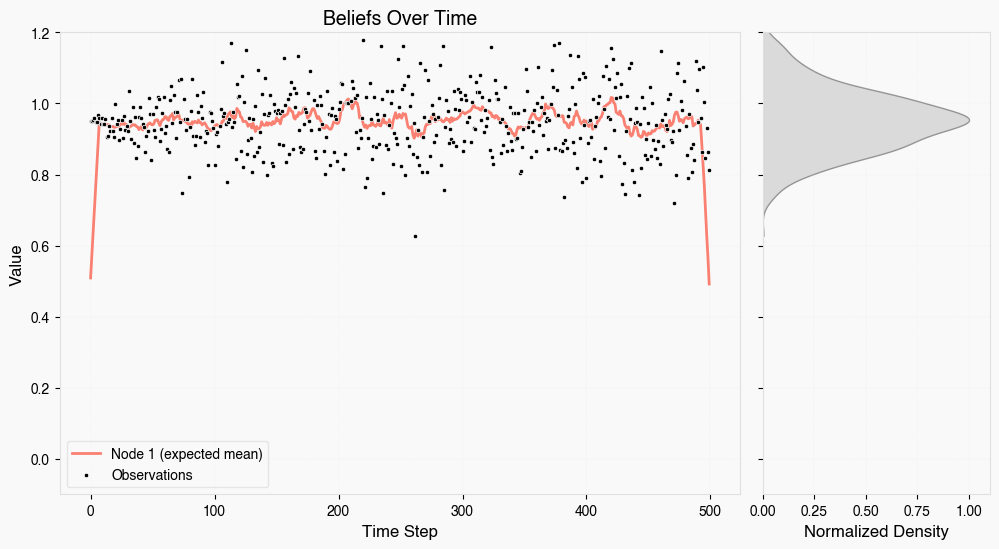

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde # NOUVEAU: Importer la fonction KDE

# --- 1. Générer des données fictives (remplacez par vos vraies données) ---
# Simule des observations qui convergent vers 0.95 avec du bruit
time_steps = 500
np.random.seed(42) # Pour des résultats reproductibles
observations = 0.95 + (np.random.randn(time_steps) * 0.1) * (1 - np.exp(-np.arange(time_steps)/50))
# Simule une moyenne mobile pour la ligne rouge
expected_mean = np.convolve(observations, np.ones(15)/15, mode='same')


# --- 2. Créer la figure et la grille pour les deux graphiques ---
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1], wspace=0.05)
ax0 = fig.add_subplot(gs[0]) 
ax1 = fig.add_subplot(gs[1], sharey=ax0)


# --- 3. Tracer le graphique temporel sur l'axe de gauche (ax0) ---
ax0.plot(expected_mean, color='salmon', lw=2, label='Node 1 (expected mean)')
ax0.scatter(range(time_steps), observations, color='black', s=10, ec='white', lw=0.5, label='Observations', zorder=10)

# Mise en forme du graphique de gauche
ax0.set_title('Beliefs Over Time')
ax0.set_xlabel('Time Step')
ax0.set_ylabel('Value')
ax0.grid(True, which='both', linestyle='--', linewidth=0.3)
ax0.legend()
ax0.set_ylim(-0.1, 1.2)


# --- 4. Tracer la courbe de densité remplie et NORMALISÉE sur l'axe de droite (ax1) ---
# 💡 SECTION MODIFIÉE

# a) Calculer la densité de probabilité (KDE) à partir des observations``
kde = gaussian_kde(observations)
# Créer une grille de valeurs Y sur laquelle évaluer la densité
y_grid = np.linspace(observations.min(), observations.max(), 500)
# Obtenir les valeurs de densité (qui seront sur notre axe X)
pdf_values = kde(y_grid)

# b) Mettre à l'échelle les valeurs de densité entre 0 et 1 (normalisation)
pdf_scaled = (pdf_values - pdf_values.min()) / (pdf_values.max() - pdf_values.min())

# c) Tracer la courbe normalisée
ax1.fill_betweenx(y_grid, pdf_scaled, color='lightgrey', alpha=0.8, edgecolor='grey')

# Mise en forme du graphique de droite
ax1.set_xlabel('Normalized Density') 
plt.setp(ax1.get_yticklabels(), visible=False)
ax1.grid(True, which='both', linestyle='--', linewidth=0.3)
# L'axe X va maintenant de 0 à 1 (avec une petite marge)
ax1.set_xlim(0, 1.1)


# --- 5. Afficher le graphique final ---
plt.show()

In [9]:
all_mus[0][0]
all_sigmas[0][0]
pdf = norm.pdf(x_vals, loc=all_mus[0][0], scale=all_sigmas[0][0])
# then into a sigmoid


Dissatisfaction (KL Divergence) over time:


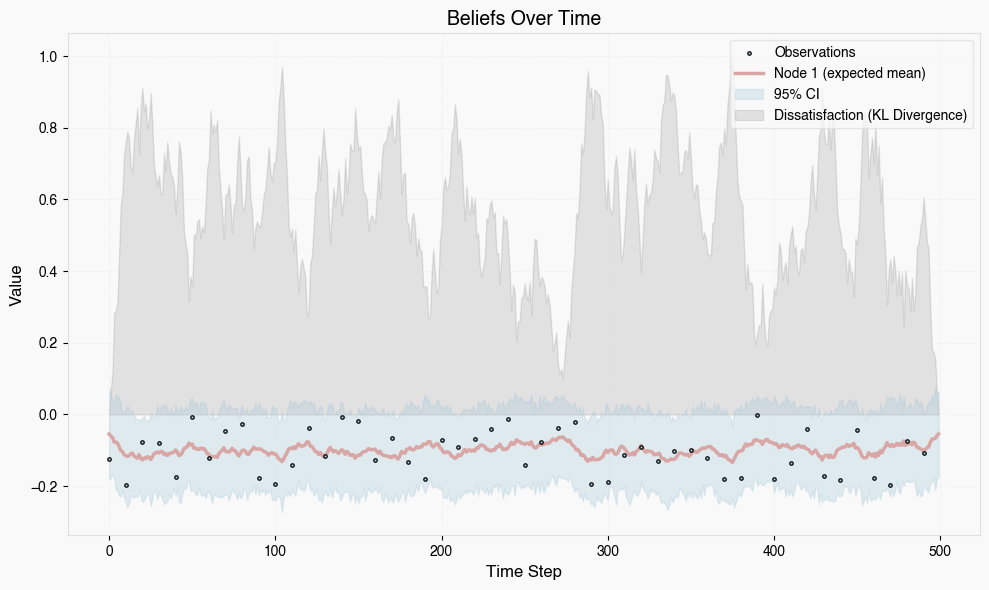

In [10]:
# --- Create agent preference network dynamically ---
network = Network()

# Add binary-state nodes
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network structure
network.plot_network()
input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1, dispersion=0)

# Feed input data into the network
network.input_data(input_data)

# Setup for dissatisfaction calculation
expected_mean = network.node_trajectories[0]["expected_mean"]
expected_precision = network.node_trajectories[0]["precision"]

# Reference preferences (baseline), same at each time step
baseline_mean = np.tile(all_mus[0][0], (len(expected_mean), 1))
baseline_precision = np.tile(all_sigmas[0][0], (len(expected_mean), 1))

# Storage for dissatisfaction at each step
dissatisfaction_over_time = []

# Compute dissatisfaction at each step
for t in range(len(expected_mean)):
    dissatisfaction = kl_divergence(
        expected_mean[t],
        expected_precision[t],  # precision is converted inside KL function
        baseline_mean[t],
        baseline_precision[t]
    )
    dissatisfaction_over_time.append(dissatisfaction)

# Display dissatisfaction over time
print("Dissatisfaction (KL Divergence) over time:")
dissatisfaction_over_time

# --- Colors (pastel) ---
obs_color = colorsys.hls_to_rgb(0.55, 0.75, 0.4)  # pastel blue
mean_color = colorsys.hls_to_rgb(0.0, 0.75, 0.4)  # pastel red
diss_color = "#181515"  # very dark gray

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of observations (every 10 points)
ax.scatter(
    range(0, len(input_data[:, 0]), 10),
    input_data[::10, 0],
    label="Observations",
    color=obs_color,
    edgecolor="k",
    alpha=0.9,
    s=6,
    zorder=3
)

# Plot expected mean
mean = network.node_trajectories[0]["expected_mean"]
ax.plot(
    mean,
    label="Node 1 (expected mean)",
    color=mean_color,
    linewidth=2.5,
    zorder=2
)

# Confidence interval (95%)
std = network.node_trajectories[0]["expected_precision"]  
upper = mean + 1.96 * std
lower = mean - 1.96 * std
ax.fill_between(
    range(len(mean)),
    lower,
    upper,
    color=obs_color,
    alpha=0.3,
    label="95% CI",
    zorder=1
)

# Normalize dissatisfaction for visualization
diss = np.array(dissatisfaction_over_time).flatten()
diss_scaled = (diss - diss.min()) / (diss.max() - diss.min())

# Add shaded area for dissatisfaction
ax.fill_between(
    range(len(dissatisfaction_over_time)),
    0,
    diss_scaled,
    label="Dissatisfaction (KL Divergence)",
    color=diss_color,
    alpha=0.1,
    zorder=0
)

# --- Titles & labels (tailles gérées globalement) ---
ax.set_title("Beliefs Over Time")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")

# --- Legend (style géré globalement) ---
ax.legend()

plt.tight_layout()
plt.show()



## Scenario 2

In [11]:

# --- Create agent preference network dynamically ---
network = Network()

# Add binary-state nodes
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network structure
network.attributes[2]["tonic_volatility"] = -1.0
network.attributes[2]

input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=2, dispersion=0)

# Feed input data into the network
network.input_data(input_data)

# Setup for dissatisfaction calculation
expected_mean = network.node_trajectories[0]["expected_mean"]
expected_precision = network.node_trajectories[0]["precision"]

# Reference preferences (baseline), same at each time step
baseline_mean = np.tile(all_mus[0][0], (len(expected_mean), 1))
baseline_precision = np.tile(all_sigmas[0][0], (len(expected_mean), 1))

# Storage for dissatisfaction at each step
dissatisfaction_over_time = []

# Compute dissatisfaction at each step
for t in range(len(expected_mean)):
    dissatisfaction = kl_divergence(
        expected_mean[t],
        expected_precision[t],  # precision is converted inside KL function
        baseline_mean[t],
        baseline_precision[t]
    )
    dissatisfaction_over_time.append(dissatisfaction)

# Display dissatisfaction over time
print("Dissatisfaction (KL Divergence) over time:")
dissatisfaction_over_time

# --- Colors (pastel) ---
obs_color = colorsys.hls_to_rgb(0.55, 0.75, 0.4)  # pastel blue
mean_color = colorsys.hls_to_rgb(0.0, 0.75, 0.4)  # pastel red
diss_color = "#181515"  # very dark gray

# --- Figure ---
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of observations (every 10 points)
ax.scatter(
    range(0, len(input_data[:, 0]), 20),
    input_data[::20, 0],
    label="Observations",
    color=obs_color,
    edgecolor="k",
    alpha=0.9,
    s=6,
    zorder=3
)

# Plot expected mean
mean = network.node_trajectories[0]["expected_mean"]
ax.plot(
    mean,
    label="Node 1 (expected mean)",
    color=mean_color,
    linewidth=2.5,
    zorder=2
)

# Confidence interval (95%) 
std = network.node_trajectories[0]["expected_precision"]  
upper = mean + 1.96 * std
lower = mean - 1.96 * std
ax.fill_between(
    range(len(mean)),
    lower,
    upper,
    color=obs_color,
    alpha=0.3,
    label="95% CI",
    zorder=1
)

# Normalize dissatisfaction for visualization
diss = np.array(dissatisfaction_over_time).flatten()
diss_scaled = (diss - diss.min()) / (diss.max() - diss.min())

# Add shaded area for dissatisfaction
ax.fill_between(
    range(len(dissatisfaction_over_time)),
    0,
    diss_scaled,
    label="Dissatisfaction (KL Divergence)",
    color=diss_color,
    alpha=0.1,
    zorder=0
)

# --- Titles & labels (tailles gérées globalement) ---
ax.set_title("Beliefs Over Time")
ax.set_xlabel("Time Step")
ax.set_ylabel("Value")

# --- Legend (style géré globalement) ---
ax.legend()

plt.tight_layout()
plt.show()

AttributeError: 'Network' object has no attribute 'attributes'

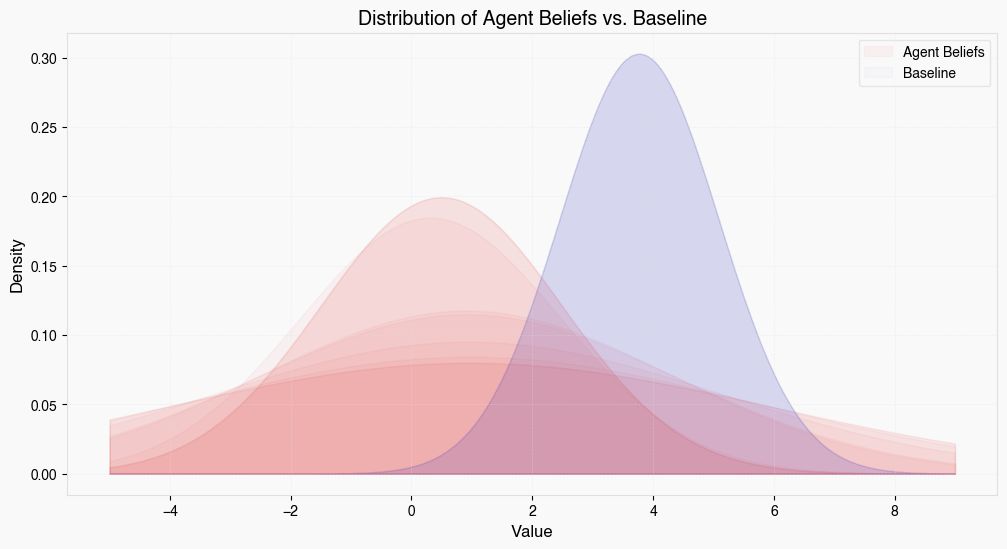

In [ ]:
# Parameters
n_steps = len(expected_mean)
x_min, x_max = -5, 9
x_vals = np.linspace(x_min, x_max, 300)

# Pastel colors
mean_color = (0.9, 0.3, 0.3)    # pastel red for beliefs
baseline_color = (0.3, 0.3, 0.9) # pastel blue for baseline
pdf_alpha = 0.05                 # transparency for each distribution

# --- Figure ---
fig, ax = plt.subplots(figsize=(12, 6))

# We only plot every 50 steps to avoid clutter
for t in range(0, n_steps, 50):
    mu = np.atleast_1d(network.node_trajectories[0]["expected_mean"][t])
    sigma = np.atleast_1d(1 / np.sqrt(network.node_trajectories[0]["precision"][t]))
    baseline_mu = np.atleast_1d(baseline_mean[t])
    baseline_sigma = np.atleast_1d(baseline_precision[t])

    # Agent belief distribution
    for m, s in zip(mu, sigma):
        pdf = norm.pdf(x_vals, loc=m, scale=s)
        ax.fill_between(x_vals, pdf, color=mean_color, alpha=pdf_alpha)

    # Reference distribution (baseline)
    for m, s in zip(baseline_mu, baseline_sigma):
        pdf = norm.pdf(x_vals, loc=m, scale=s)
        ax.fill_between(x_vals, pdf, color=baseline_color, alpha=0.02)

ax.set_title("Distribution of Agent Beliefs vs. Baseline")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend(["Agent Beliefs", "Baseline"], loc="upper right")
plt.show()

# Plot 3 - Voting

In [ ]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

input_data = generate_observations(n_nodes=n_preferences, n_steps=500, scenario=1, dispersion=0)

# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes, softmax, dissatisfactions = vmap_get_votes_fn(all_mus, all_pis, tonic_volatilities, keys)

In [ ]:
# Split into n simulations
sim_votes = np.array_split(votes, n_simulations)
sim_diss = np.array_split(dissatisfactions, n_simulations)  # split dissatisfaction too

# Prepare a list to store per-simulation stats
rows = []

for i, (vote_chunk, diss_chunk) in enumerate(zip(sim_votes, sim_diss)):
    total_votes = len(vote_chunk)
    unique, counts = np.unique(vote_chunk, return_counts=True)
    
    # Compute mean dissatisfaction per candidate for this simulation
    mean_diss = np.mean(diss_chunk, axis=0)  # shape = (n_candidates,)
    mean_diss = np.array(mean_diss, dtype=float)
    
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,       # simulation index 1–100
            'candidate': candidate,           # candidate ID (int)
            'votes': count,                   # raw votes per candidate ✅
            'proportion': count / total_votes,
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,votes,proportion,candidate_id
0,1,0,100,1.00,0
1,2,0,100,1.00,0
2,3,0,100,1.00,0
3,4,0,100,1.00,0
4,5,0,100,1.00,0
...,...,...,...,...,...
121,98,0,100,1.00,0
122,99,0,99,0.99,0
123,99,1,1,0.01,1
124,100,0,99,0.99,0


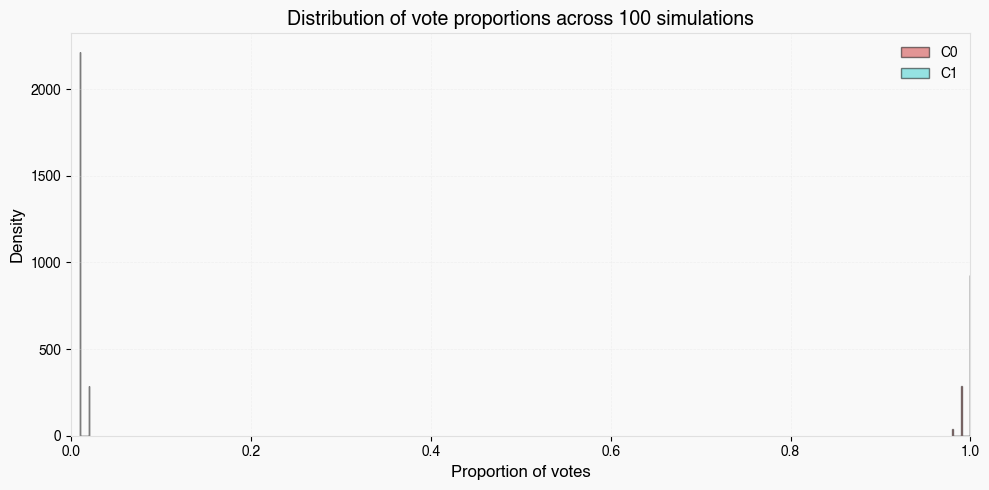

In [ ]:
# Higher contrast colors for candidates
candidate_ids = df_simulations["candidate_id"].unique()
n_cand = len(candidate_ids)
colors = [colorsys.hls_to_rgb(i / n_cand, 0.5, 0.6) for i in range(n_cand)]  # darker colors

# Plot distributions
fig, ax = plt.subplots(figsize=(10, 5))

for i, cid in enumerate(candidate_ids):
    proportions = df_simulations.loc[df_simulations["candidate_id"] == cid, "proportion"]
    ax.hist(
        proportions, bins=25, density=True,
        alpha=0.5, color=colors[i], edgecolor="black",
        label=f"C{cid}", rwidth=1, histtype="stepfilled"
    )

# Labels and title (tailles déjà définies globalement)
ax.set_xlabel("Proportion of votes")
ax.set_ylabel("Density")
ax.set_title(
    f"Distribution of vote proportions across {df_simulations['simulation_number'].nunique()} simulations"
)

# Legend (style géré globalement)
ax.legend(frameon=False)

# Limits (utile donc à garder)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


Résumé des statistiques :
         Candidat      mean       std    ci_low   ci_high
0  Candidat Alpha  0.627453  0.093367  0.600918  0.653987
1   Candidat Beta  0.722134  0.104919  0.692316  0.751951
2  Candidat Gamma  0.576857  0.081233  0.553771  0.599943


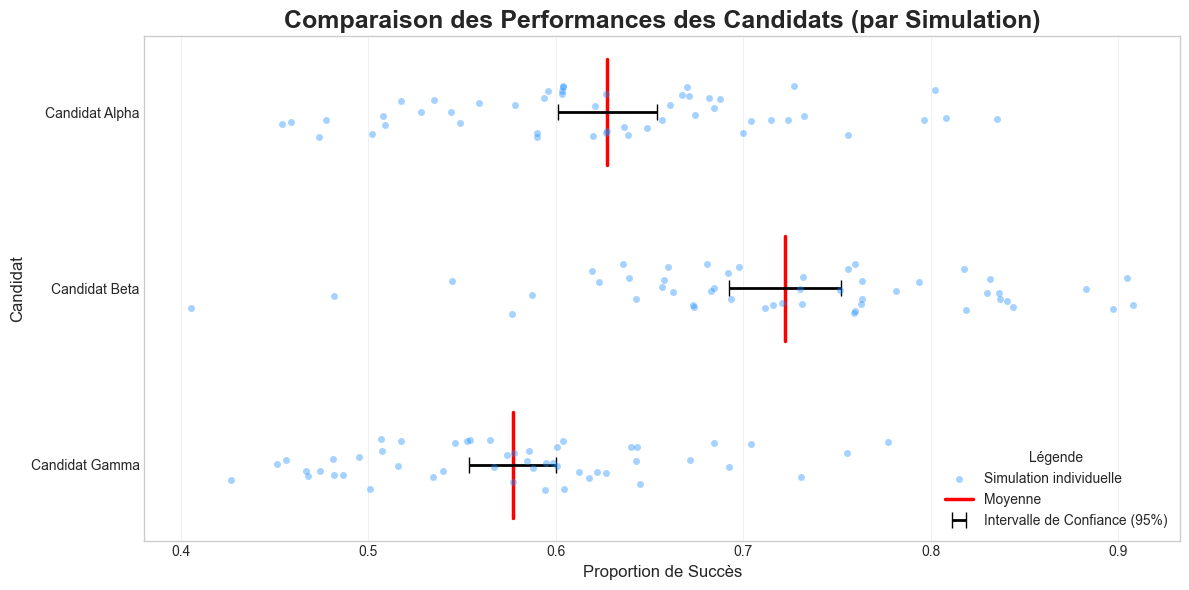

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# --- 1. Génération de données d'exemple ---
# Les données simulent la proportion de succès pour 3 candidats sur 50 simulations chacun.
np.random.seed(42) # Pour la reproductibilité
data = {
    'Candidat Alpha': np.random.normal(0.65, 0.1, 50),
    'Candidat Beta': np.random.normal(0.72, 0.12, 50),
    'Candidat Gamma': np.random.normal(0.58, 0.08, 50)
}

# Conversion en DataFrame "long"
df = pd.DataFrame(data).melt(var_name='Candidat', value_name='Proportion')

# On s'assure que les proportions restent entre 0 et 1
df['Proportion'] = df['Proportion'].clip(0, 1)


# --- 2. Calcul des statistiques ---
# On regroupe par candidat pour calculer la moyenne et l'intervalle de confiance
summary_stats = df.groupby('Candidat')['Proportion'].agg(['mean', 'std']).reset_index()

# Fonction pour calculer l'intervalle de confiance à 95%
def confidence_interval(data):
    return stats.t.interval(confidence=0.95, df=len(data)-1, loc=np.mean(data), scale=stats.sem(data))

ci_data = df.groupby('Candidat')['Proportion'].apply(confidence_interval).apply(pd.Series)
ci_data.columns = ['ci_low', 'ci_high']

# Fusion des statistiques
summary_stats = summary_stats.merge(ci_data, left_on='Candidat', right_index=True)

print("Résumé des statistiques :")
print(summary_stats)


# --- 3. Création du graphique ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))

# **Changement principal : on inverse x et y ici**
# Stripplot pour afficher chaque simulation (chaque point)
sns.stripplot(
    data=df,
    x='Proportion',
    y='Candidat',
    jitter=0.15,      # Dispersion verticale pour éviter la superposition
    alpha=0.4,        # Transparence des points
    color='dodgerblue',
    ax=ax,
    label='Simulation individuelle'
)

# Ajout des statistiques par-dessus le nuage de points
for i, candidate_name in enumerate(summary_stats['Candidat']):
    stats_row = summary_stats.iloc[i]
    mean = stats_row['mean']
    ci_low = stats_row['ci_low']
    ci_high = stats_row['ci_high']

    # Ligne verticale pour la MOYENNE
    ax.plot([mean, mean], [i-0.3, i+0.3], color='red', lw=2.5, label='Moyenne' if i == 0 else "")

    # Barre d'erreur horizontale pour l'INTERVALLE DE CONFIANCE à 95%
    ax.errorbar(
        x=mean,
        y=i,
        # **Changement : on utilise xerr au lieu de yerr**
        xerr=[[mean - ci_low], [ci_high - mean]],
        fmt='none',
        color='black',
        capsize=6,
        lw=2,
        label='Intervalle de Confiance (95%)' if i == 0 else ""
    )

# --- 4. Amélioration et finalisation ---
ax.set_title('Comparaison des Performances des Candidats (par Simulation)', fontsize=18, fontweight='bold')
ax.set_xlabel('Proportion de Succès', fontsize=12)
ax.set_ylabel('Candidat', fontsize=12)
ax.xaxis.grid(True) # Garde la grille verticale pour mieux lire les proportions

# Création d'une légende propre et unique
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Légende', loc='best')

# Améliore les marges pour que tout soit visible
plt.tight_layout()
plt.show()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_40657/3895879775.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_40657/3895879775.py:8: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


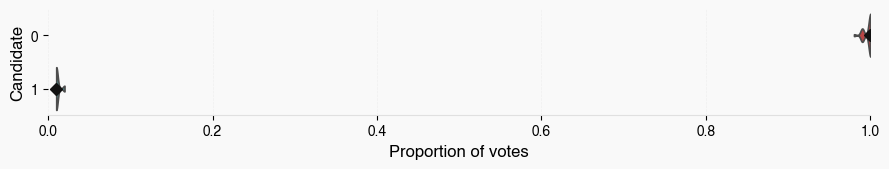

In [ ]:
df_plot = df_simulations.copy()
df_plot["candidate_id"] = df_plot["candidate_id"].astype(str)
candidate_order_str = [str(c) for c in sorted(df_simulations["candidate_id"].unique())]

fig, ax = plt.subplots(figsize=(9, 0.9 * len(candidate_order_str)))

# width-scaled violins without inner (to stay minimal)
sns.violinplot(
    data=df_plot,
    x="proportion",
    y="candidate_id",
    order=candidate_order_str,
    palette=[colors[i % len(colors)] for i in range(len(candidate_order_str))],
    inner=None,    # no inner violin to keep the style clean
    cut=0,
    scale="width",
    ax=ax
)


# median + short line for each candidate
grouped = df_plot.groupby("candidate_id")["proportion"]
for i, cid in enumerate(candidate_order_str):
    vals = grouped.get_group(cid).values
    med = np.median(vals)
    ax.plot(med, i, marker='D', markersize=6, color='#111')

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of votes")
ax.set_ylabel("Candidate")
sns.despine(trim=True, left=True)
plt.tight_layout()
plt.show()

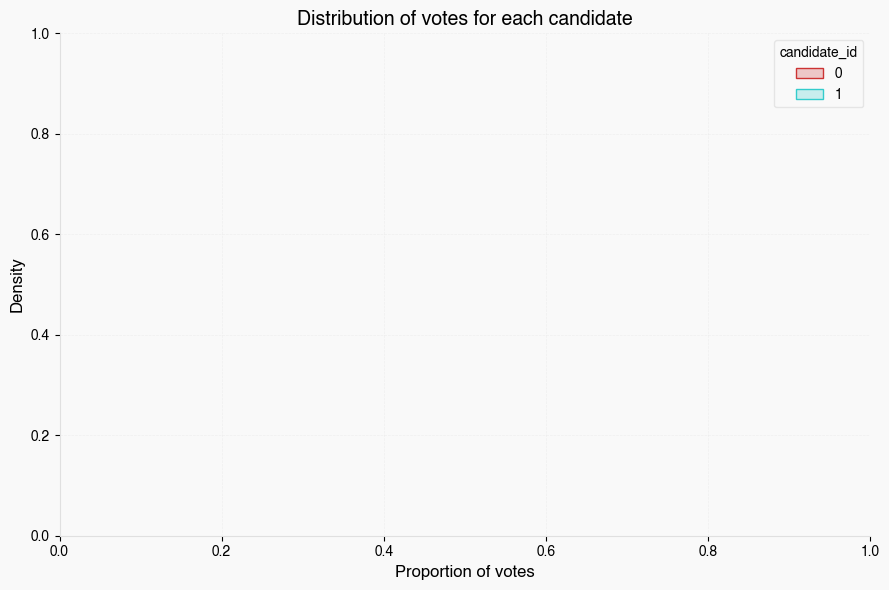

In [ ]:

df_plot = df_simulations.copy()
df_plot["candidate_id"] = df_plot["candidate_id"].astype(str)
candidate_order_str = sorted(df_simulations["candidate_id"].unique())

fig, ax = plt.subplots(figsize=(9, 6))

# Plot the KDEs with 'hue' for candidates and 'y' for density
sns.kdeplot(
    data=df_plot,
    x="proportion",
    hue="candidate_id",
    hue_order=candidate_order_str,
    palette=[colors[i % len(colors)] for i in range(len(candidate_order_str))],
    fill=True,
    ax=ax
)

ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of votes")
ax.set_ylabel("Density")
ax.set_title("Distribution of votes for each candidate")

# The legend is automatically handled by the 'hue' parameter in seaborn
# You can further customize it if needed

sns.despine(trim=True)
plt.tight_layout()
plt.show()

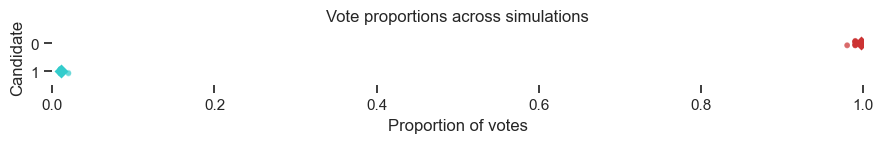

In [ ]:
# --- Style global pour seaborn (ticks) ---
sns.set_theme(style="ticks")

# --- Préparer les données ---
df_plot = df_simulations.copy()
df_plot["candidate_id"] = df_plot["candidate_id"].astype(str)

# --- Figure ---
fig, ax = plt.subplots(figsize=(9, 0.8 * df_plot["candidate_id"].nunique()))
sns.despine(bottom=True, left=True)

# --- Palette pastel pour les candidats ---
pastel_palette = [colors[i % len(colors)] for i in range(df_plot["candidate_id"].nunique())]

# --- Points individuels (chaque simulation) ---
sns.stripplot(
    data=df_plot,
    x="proportion",
    y="candidate_id",
    hue="candidate_id",
    dodge=False,
    alpha=0.35,
    zorder=1,
    palette=pastel_palette,
    size=4,
    legend=False
)

# --- Médianes par candidat ---
sns.pointplot(
    data=df_plot,
    x="proportion",
    y="candidate_id",
    hue="candidate_id",
    dodge=False,
    palette=pastel_palette,
    errorbar=None,
    markers="D",
    markersize=5,
    linestyle="none",
    ax=ax,
    legend=False
)

# --- Labels et titres (tailles cohérentes avec rcParams) ---
ax.set_xlim(0, 1)
ax.set_xlabel("Proportion of votes")
ax.set_ylabel("Candidate")
ax.set_title("Vote proportions across simulations")

plt.tight_layout()
plt.show()
